# 02 — Exploratory Data Analysis

**Prerequisite:** run `python src/build_eda_aggregates.py` once. The raw performance
panels (`panel_logistic_2021_2025.parquet` ≈ 329M rows, `panel_cph_2018_2025.parquet`
≈ 592M rows) are far too large to load into a Jupyter kernel — doing so OOM-kills it.
The script aggregates them out-of-core with DuckDB into small parquet files
(`eda_loan_level.parquet`, `eda_delinq_counts.parquet`, `eda_zbc_counts.parquet`,
`eda_vintage.parquet`) that this notebook loads cheaply.

Covers spec §10 Phase 3 charts:
1. Distributions of FICO, LTV, DTI by origination cohort
2. Default rate by FICO bucket, LTV bucket, property state
3. FICO vs. Default boxplot
4. Delinquency status distribution
5. Loan age distribution (right-censoring check)
6. Zero balance code breakdown
7. Vintage default rate chart (by origination quarter)

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()
sys.path.insert(0, str(Path('..') / 'src'))

sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

PROCESSED = Path('..') / 'data' / 'processed'
FIGURES   = Path('..') / 'artifacts' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

In [2]:
# The raw panels are 329M / 592M rows (tens of GB in RAM) and OOM-kill the kernel if
# loaded here. Instead we load the small precomputed aggregates produced out-of-core
# by src/build_eda_aggregates.py. Run that script once first:
#     python src/build_eda_aggregates.py
# We read only the columns the charts use (loan_id and other strings would balloon the
# 9M-row frame to ~3 GB as Python objects), so this cell stays well under ~1.5 GB.
_cols = ['credit_score', 'ltv', 'dti', 'orig_loan_term', 'property_state',
         'orig_year', 'is_default', 'max_loan_age']
loan_level = (
    pd.read_parquet(PROCESSED / 'eda_loan_level.parquet', columns=_cols)
    .rename(columns={'is_default': 'default'})
)
loan_level['property_state'] = loan_level['property_state'].astype('category')

# Performance-row count comes from the panel's parquet footer (metadata only, no data load)
n_perf = pq.ParquetFile(PROCESSED / 'panel_logistic_2021_2025.parquet').metadata.num_rows

print(f'Panel (2021-2025): {n_perf:,} performance rows, {loan_level.shape[0]:,} unique loans')
print(f'Loan-level default rate: {loan_level["default"].mean():.4%}')

Panel (2021-2025): 328,974,226 performance rows, 9,143,428 unique loans
Loan-level default rate: 1.7190%


## 1. Distributions of FICO, LTV, DTI by origination cohort

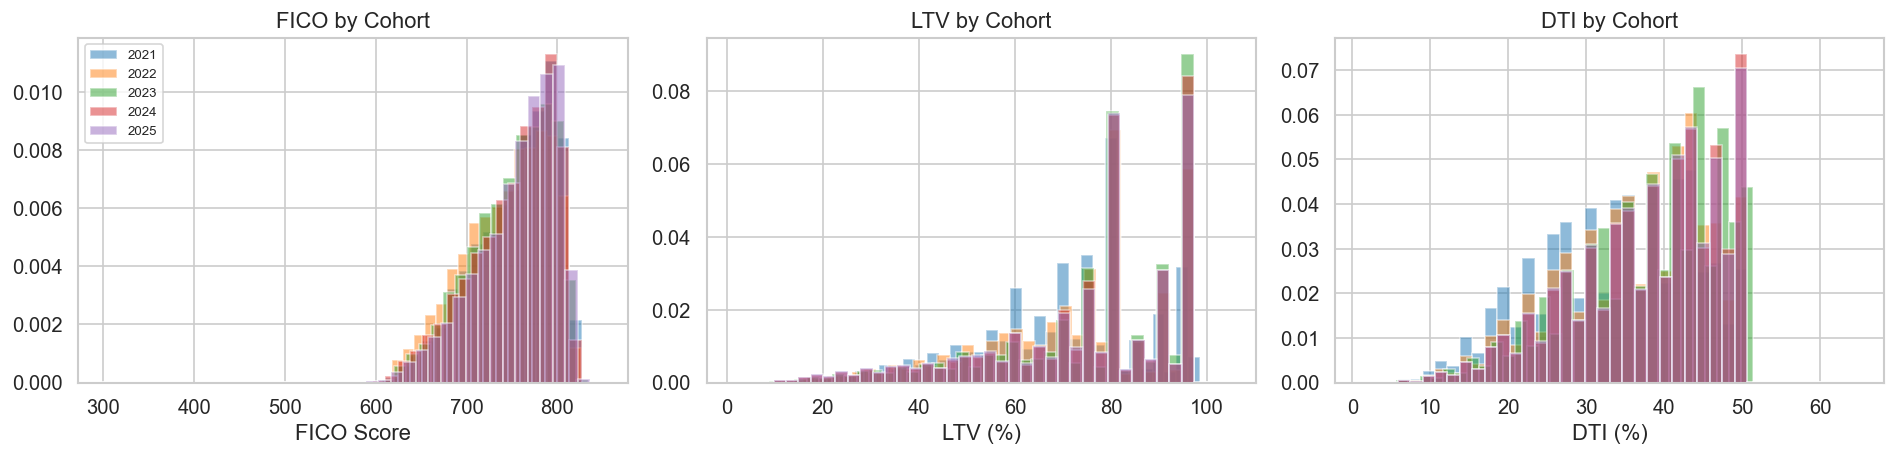

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for year, grp in loan_level.groupby('orig_year'):
    axes[0].hist(grp['credit_score'].dropna(), bins=40, alpha=0.5, label=str(year), density=True)
    axes[1].hist(grp['ltv'].dropna().clip(0, 105), bins=40, alpha=0.5, density=True)
    axes[2].hist(grp['dti'].dropna().clip(0, 65), bins=40, alpha=0.5, density=True)

axes[0].set_xlabel('FICO Score'); axes[0].set_title('FICO by Cohort'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('LTV (%)');    axes[1].set_title('LTV by Cohort')
axes[2].set_xlabel('DTI (%)');    axes[2].set_title('DTI by Cohort')

plt.tight_layout()
plt.savefig(FIGURES / 'eda_fico_ltv_dti_distributions.png', bbox_inches='tight')
plt.show()

## 2. Default rate by FICO bucket, LTV bucket, property state

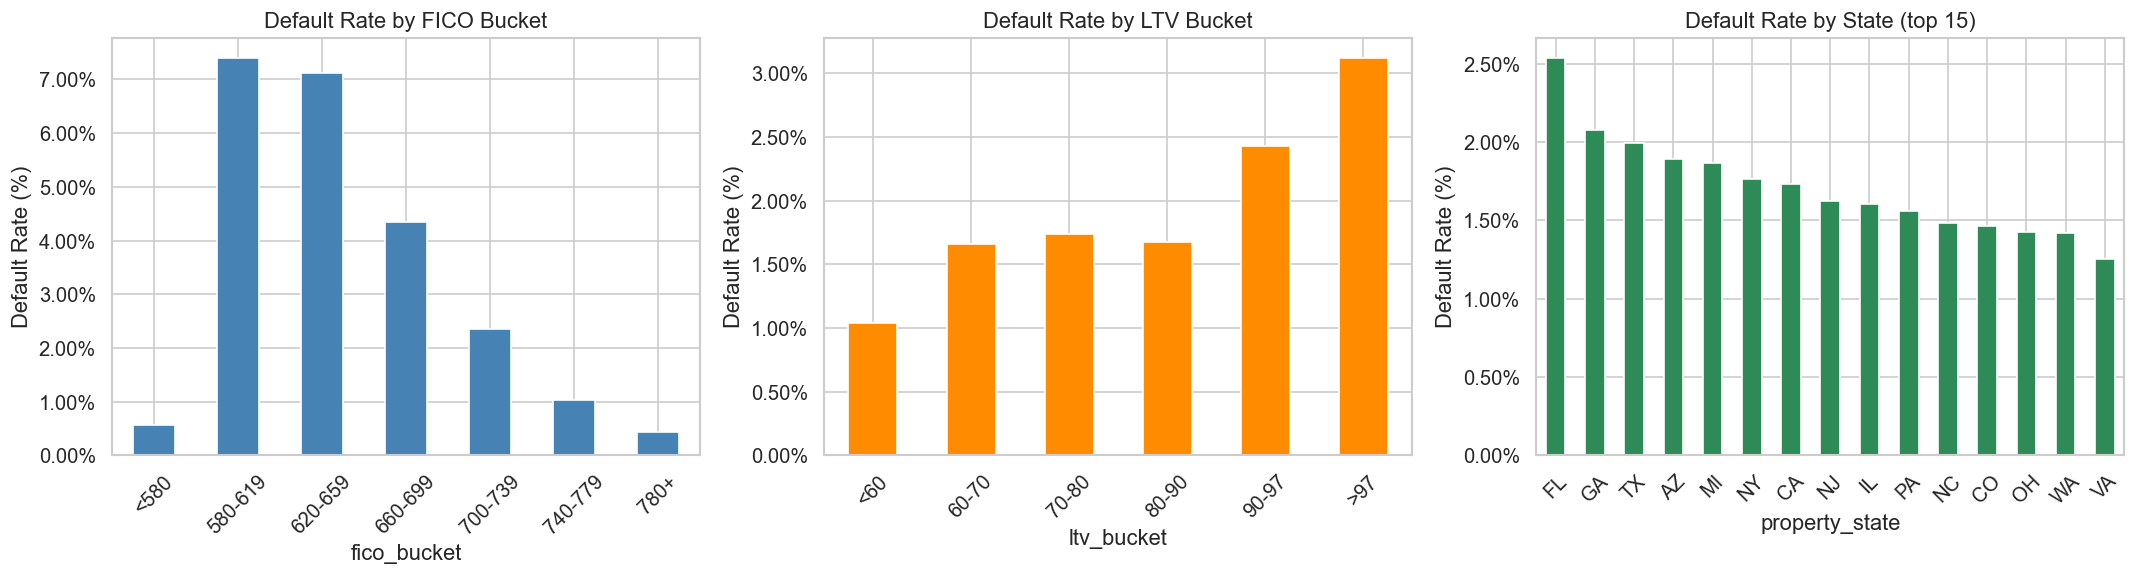

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# FICO buckets
fico_bins = [300, 580, 620, 660, 700, 740, 780, 850]
fico_labels = ['<580', '580-619', '620-659', '660-699', '700-739', '740-779', '780+']
loan_level['fico_bucket'] = pd.cut(
    loan_level['credit_score'], bins=fico_bins, labels=fico_labels, right=False
)
fico_dr = loan_level.groupby('fico_bucket', observed=True)['default'].mean() * 100
fico_dr.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Default Rate by FICO Bucket')
axes[0].set_ylabel('Default Rate (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))

# LTV buckets
ltv_bins = [0, 60, 70, 80, 90, 97, 105]
ltv_labels = ['<60', '60-70', '70-80', '80-90', '90-97', '>97']
loan_level['ltv_bucket'] = pd.cut(
    loan_level['ltv'], bins=ltv_bins, labels=ltv_labels, right=False
)
ltv_dr = loan_level.groupby('ltv_bucket', observed=True)['default'].mean() * 100
ltv_dr.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Default Rate by LTV Bucket')
axes[1].set_ylabel('Default Rate (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))

# Top 15 states by loan count
top_states = loan_level['property_state'].value_counts().head(15).index
state_dr = (
    loan_level[loan_level['property_state'].isin(top_states)]
    .groupby('property_state', observed=True)['default'].mean()
    .mul(100)
    .sort_values(ascending=False)
)
state_dr.plot(kind='bar', ax=axes[2], color='seagreen', edgecolor='white')
axes[2].set_title('Default Rate by State (top 15)')
axes[2].set_ylabel('Default Rate (%)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))

plt.tight_layout()
plt.savefig(FIGURES / 'eda_default_rate_by_segment.png', bbox_inches='tight')
plt.show()

## 3. FICO vs. Default boxplot

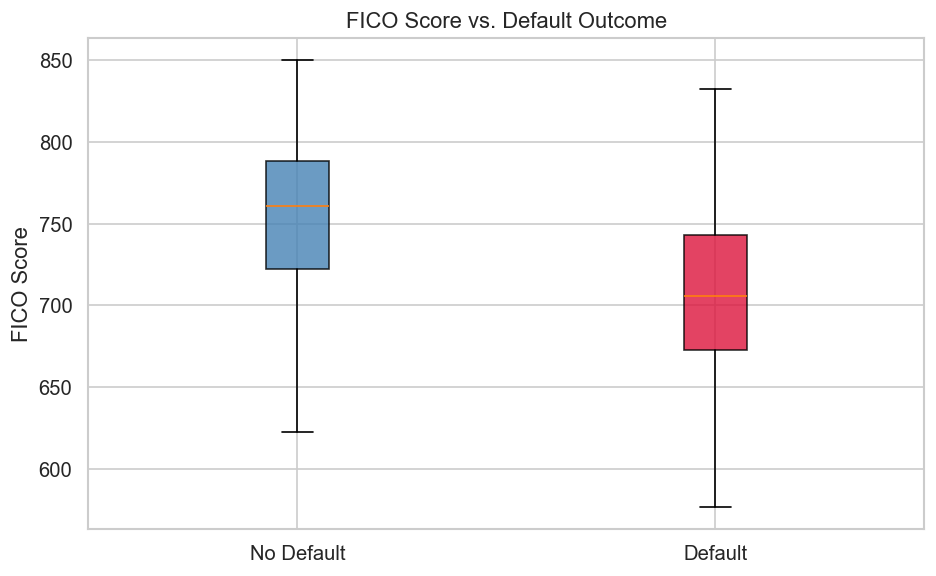

Median FICO | No Default: 761
Median FICO | Default:    706


In [5]:
# Plain matplotlib boxplot on two arrays — seaborn's boxplot copies the whole 9M-row
# frame and renders millions of outlier points (~2 GB spike); this stays light.
# Tick labels are set manually so this works on any matplotlib version (the boxplot
# `tick_labels`/`labels` kwarg name changed across versions).
fig, ax = plt.subplots(figsize=(8, 5))
cs = loan_level['credit_score']
no_default = cs[loan_level['default'] == 0].dropna().to_numpy()
default    = cs[loan_level['default'] == 1].dropna().to_numpy()

bp = ax.boxplot([no_default, default], patch_artist=True, showfliers=False)
ax.set_xticks([1, 2])
ax.set_xticklabels(['No Default', 'Default'])
for patch, color in zip(bp['boxes'], ['steelblue', 'crimson']):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_title('FICO Score vs. Default Outcome')
ax.set_xlabel('')
ax.set_ylabel('FICO Score')
plt.tight_layout()
plt.savefig(FIGURES / 'eda_fico_vs_default_boxplot.png', bbox_inches='tight')
plt.show()

print(f"Median FICO | No Default: {np.median(no_default):.0f}")
print(f"Median FICO | Default:    {np.median(default):.0f}")

## 4. Delinquency status distribution

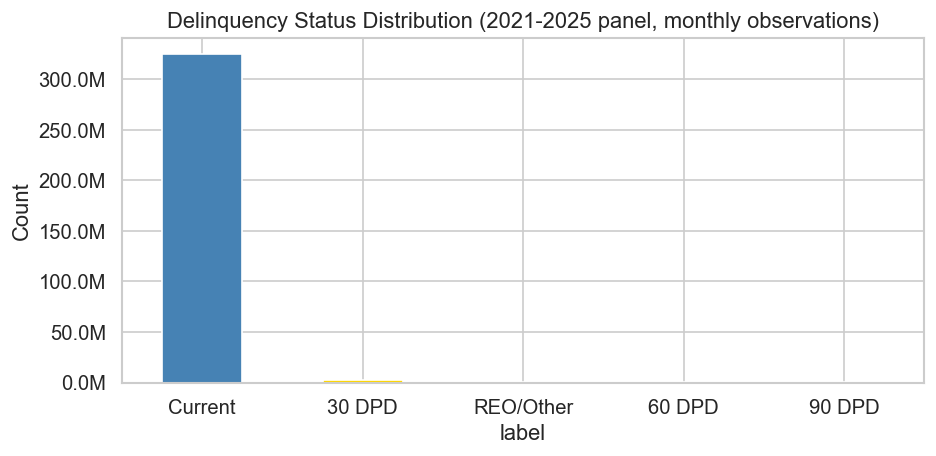

label
Current      325148477
30 DPD         2249777
REO/Other       832264
60 DPD          500021
90 DPD          243687
Name: n, dtype: int64


In [6]:
delinq_map = {'0': 'Current', '1': '30 DPD', '2': '60 DPD', '3': '90 DPD'}

# Precomputed value counts over the 329M monthly observations
_dq = pd.read_parquet(PROCESSED / 'eda_delinq_counts.parquet')
_dq['label'] = (
    _dq['delinquency_status']
    .where(_dq['delinquency_status'].isin(delinq_map))
    .map(delinq_map)
    .fillna('REO/Other')
)
delinq_counts = _dq.groupby('label')['n'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
delinq_counts.plot(kind='bar', ax=ax, color=['steelblue','gold','darkorange','crimson','purple'])
ax.set_title('Delinquency Status Distribution (2021-2025 panel, monthly observations)')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig(FIGURES / 'eda_delinquency_distribution.png', bbox_inches='tight')
plt.show()

print(delinq_counts)

## 5. Loan age distribution (right-censoring check)

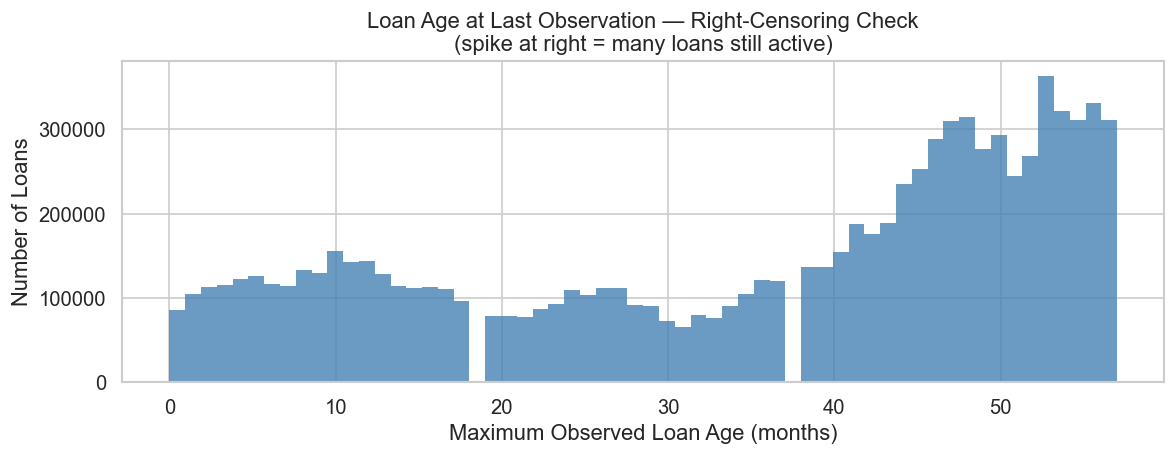

29.4% of loans have fewer than 24 months of history (heavily censored — Cox PH handles this)


In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(
    loan_level['max_loan_age'].clip(0, 60), bins=60,
    color='steelblue', edgecolor='none', alpha=0.8
)
ax.set_xlabel('Maximum Observed Loan Age (months)')
ax.set_ylabel('Number of Loans')
ax.set_title('Loan Age at Last Observation — Right-Censoring Check\n(spike at right = many loans still active)')
plt.tight_layout()
plt.savefig(FIGURES / 'eda_loan_age_distribution.png', bbox_inches='tight')
plt.show()

pct_young = (loan_level['max_loan_age'] < 24).mean()
print(f'{pct_young:.1%} of loans have fewer than 24 months of history (heavily censored — Cox PH handles this)')

## 6. Zero balance code breakdown

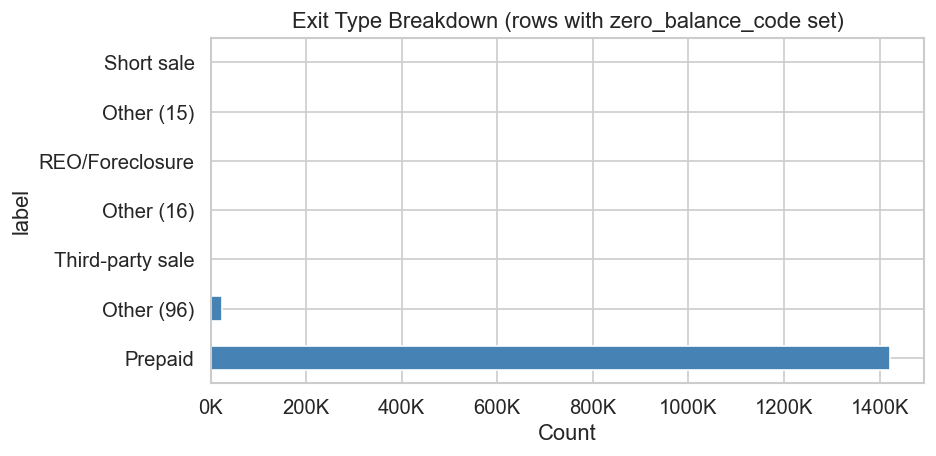

label
Prepaid             1422617
Other (96)            24909
Third-party sale       1167
Other (16)             1121
REO/Foreclosure        1086
Other (15)              317
Short sale              214
Name: n, dtype: int64


In [8]:
zbc_map = {
    '01': 'Prepaid',
    '02': 'Third-party sale',
    '03': 'Short sale',
    '06': 'Repurchase',
    '09': 'REO/Foreclosure',
}
# Precomputed exit-code counts (rows with zero_balance_code set)
_zb = pd.read_parquet(PROCESSED / 'eda_zbc_counts.parquet')
_zb['label'] = _zb['zero_balance_code'].map(lambda x: zbc_map.get(str(x).strip(), f'Other ({x})'))
zbc = _zb.groupby('label')['n'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
zbc.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Exit Type Breakdown (rows with zero_balance_code set)')
ax.set_xlabel('Count')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
plt.tight_layout()
plt.savefig(FIGURES / 'eda_zero_balance_breakdown.png', bbox_inches='tight')
plt.show()

print(zbc)

## 7. Vintage default rate chart (by origination quarter)

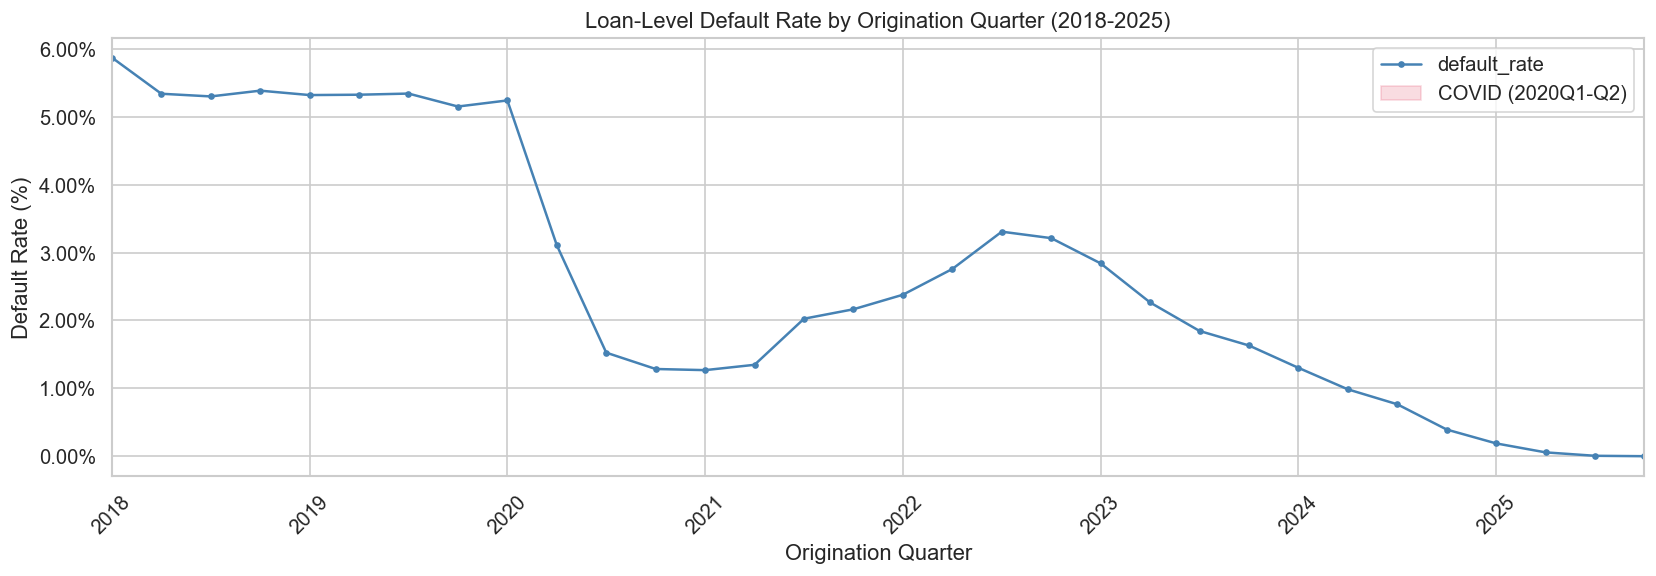

In [9]:
# Precomputed loan-level default rate by origination quarter over the full CPH panel
# (2018-2025). Rebuild a PeriodIndex so the COVID annotation below works.
_v = pd.read_parquet(PROCESSED / 'eda_vintage.parquet')
vintage = _v.set_index('orig_quarter')['default_rate']
vintage.index = pd.PeriodIndex(vintage.index, freq='Q')
vintage = vintage.sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
vintage.plot(ax=ax, marker='o', markersize=3, linewidth=1.5, color='steelblue')
ax.set_title('Loan-Level Default Rate by Origination Quarter (2018-2025)')
ax.set_xlabel('Origination Quarter')
ax.set_ylabel('Default Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
ax.tick_params(axis='x', rotation=45)

# Annotate COVID cohort
if '2020Q1' in vintage.index.astype(str):
    ax.axvspan(
        vintage.index.get_loc('2020Q1') - 0.5,
        vintage.index.get_loc('2020Q2') + 0.5,
        alpha=0.15, color='crimson', label='COVID (2020Q1-Q2)'
    )
    ax.legend()

plt.tight_layout()
plt.savefig(FIGURES / 'eda_vintage_default_rates.png', bbox_inches='tight')
plt.show()

In [10]:
# Summary statistics table
print('=== Summary Statistics (loan level, 2021-2025) ===')
summary = loan_level[['credit_score', 'ltv', 'dti', 'orig_loan_term']].describe().round(1)
print(summary.to_string())

=== Summary Statistics (loan level, 2021-2025) ===
       credit_score        ltv        dti  orig_loan_term
count     9141537.0  9143428.0  9142735.0       9143428.0
mean          750.9       71.5       35.5           330.3
std            45.1       18.3        9.6            65.0
min           300.0        1.0        1.0            85.0
25%           721.0       60.0       29.0           360.0
50%           760.0       75.0       37.0           360.0
75%           788.0       85.0       43.0           360.0
max           850.0      365.0       65.0           510.0
